# Property Scanner: Multimodal AI Valuation System

## 1. Project Overview
**Objective**: Predict property prices in Spanish cities (Madrid, Barcelona, etc.) using a **Multimodal Late-Fusion Model**.

**Key Innovation**: Unlike traditional comparable approaches that only use numbers (sqm, rooms), this system "sees" the property using a **Vision Language Model (VLM)** to extract qualitative features (condition, style, finishes) from images and fuses them with quantitative data.


## 2. System Architecture

The system uses a state-of-the-art **Agentic Pipeline** to transform raw web data into reasoned valuations.

### Pipeline Stages:
1.  **Extraction Agent**: Scrapes and normalizes raw data into `CanonicalListing` objects.
2.  **Vision Agent (VLM)**: Deep-inspects photos using **Llava/Ollama** to describe interiors and finishes.
3.  **Embedding Engine**: Converts text and descriptions into **384D vectors** via SentenceTransformers.
4.  **Fusion Model**: A custom PyTorch model that performs **Cross-Attention** between the target property and local market comparables.


## 3. Data Inspection

Let's look at the data collected in `data/listings.db`.

In [165]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import ast
import json
import seaborn as sns
import sys
import os

# Ensure we can import from src
sys.path.append('..')

# Connect to Database
conn = sqlite3.connect('../data/listings.db')
df = pd.read_sql_query("SELECT * FROM listings WHERE price > 0", conn)
conn.close()

print(f"Total Listings: {len(df)}")
display(df[['id', 'title', 'price', 'city', 'vlm_description']].head())

Total Listings: 1701


,id,title,price,city,vlm_description
0,d01dfab5724aafce35f0e15411d42171,Casa adosada en Pasaje Fuente Del Cura,255000.0,Unknown,None
1,f5eda6e9644ffb6057269c04b33d5627,"Chalet en Avenida de La Cabrera, 27",459000.0,Unknown,None
2,fb8b62a11196330e3baa10b614d0c52b,Chalet en calle Centro,409000.0,Unknown,None
3,9ed098ec6c11752ef44c44427db67c15,Chalet en Carretera de Valdemanco,409000.0,Unknown,None
4,eb20d968e7e3083f043a0b4a8af93aa4,Piso en calle de Almansa,850000.0,Unknown,None


### 3.1 Market Composition: City Breakdown
Where is our data coming from? We've expanded to include the most active real estate markets in Spain.

/var/folders/dc/xp5rn2p562g61yp_f0n6mxl40000gn/T/ipykernel_6321/3550406612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index, y=city_counts.values, palette='viridis')


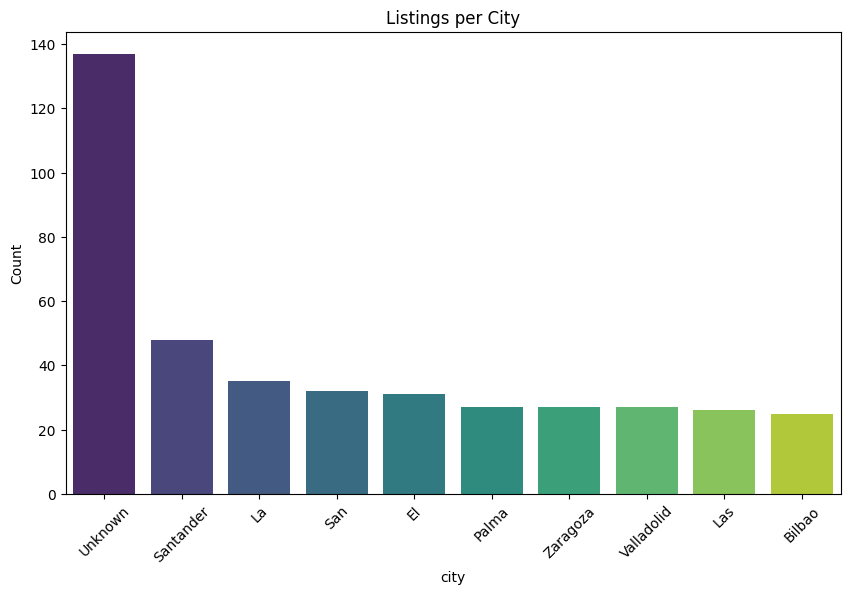

In [166]:
plt.figure(figsize=(10, 6))
city_counts = df['city'].value_counts()[:10]
sns.barplot(x=city_counts.index, y=city_counts.values, palette='viridis')
plt.title('Listings per City')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

### 3.2 Geospatial Analysis
Visualizing the spatial density of our properties.

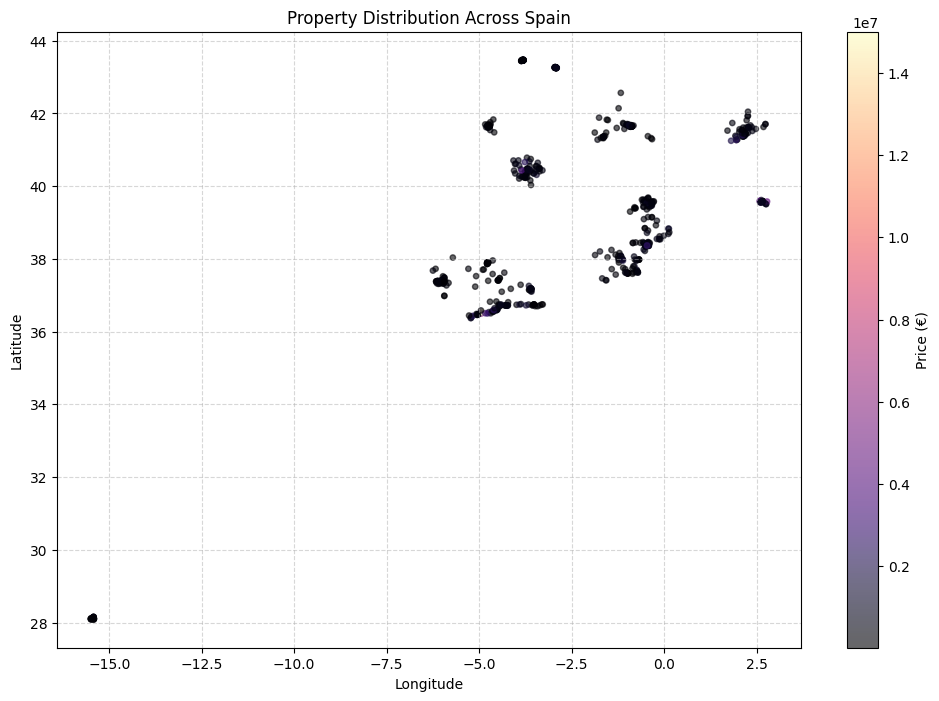

In [167]:
# Filter out valid coordinates
geo_df = df[(df['lat'] != 0) & (df['lon'] != 0)]

plt.figure(figsize=(12, 8))
plt.scatter(geo_df['lon'], geo_df['lat'], c=geo_df['price'], cmap='magma', s=15, alpha=0.6)
plt.colorbar(label='Price (€)')
plt.title('Property Distribution Across Spain')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 3.3 Data Quality Analysis

Understanding data completeness is crucial. The chart below visualizes the percentage of missing values for each feature in our dataset.

/var/folders/dc/xp5rn2p562g61yp_f0n6mxl40000gn/T/ipykernel_6321/1432240471.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_props.values, y=missing_props.index, palette='magma')


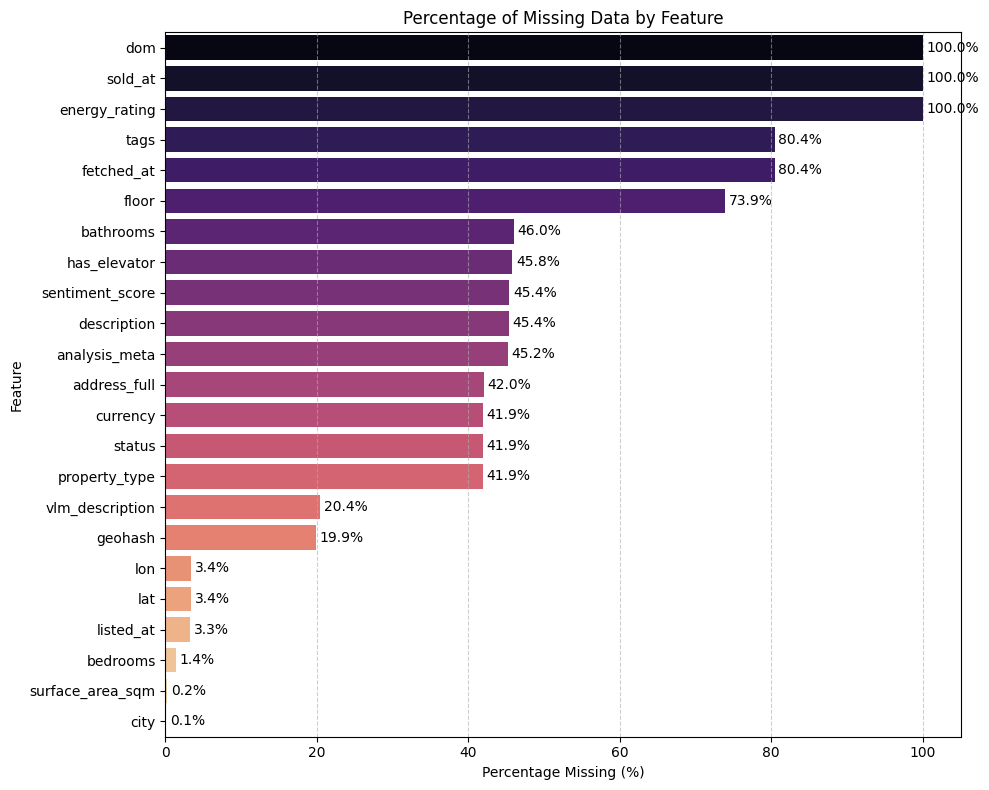

In [168]:
# Connect to Database to get full dataset
conn = sqlite3.connect('../data/listings.db')
quality_df = pd.read_sql_query("SELECT * FROM listings", conn)
conn.close()

# Calculate missing percentages
missing_props = quality_df.isnull().sum() / len(quality_df) * 100
# Filter properties that actually have missing data
missing_props = missing_props[missing_props > 0].sort_values(ascending=False)

if not missing_props.empty:
    # Visualize
    plt.figure(figsize=(10, 8))
    sns.barplot(x=missing_props.values, y=missing_props.index, palette='magma')
    plt.title('Percentage of Missing Data by Feature')
    plt.xlabel('Percentage Missing (%)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Add value labels
    for i, v in enumerate(missing_props.values):
        plt.text(v + 0.5, i, f"{v:.1f}%", va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("Amazing! No missing data found in the dataset.")

## 4. VLM: The Visual Intelligence

Traditional models miss detail. Our VLM captures descriptions like *"modern open-concept kitchen"* or *"ranch-style villa with pool"*.

In [169]:
vlm_enriched = df[df['vlm_description'].notna() & (df['vlm_description'] != '')]
print(f"Enriched Listings: {len(vlm_enriched)}")

if not vlm_enriched.empty:
    sample = vlm_enriched.sample(1).iloc[0]
    print(f"\nProperty: {sample['title']}")
    print("VLM Insight:", sample['vlm_description'][:400] + "...")

Enriched Listings: 1355

Property: Piso en venta en Calle del Pintor Fernando Soria, 12
VLM Insight:  The image depicts a residential property with outdoor spaces. Here's an analysis:

1. Room type: This is a single-family house with exterior areas including a swimming pool and patio.
2. Condition: The property appears to be in excellent condition, recently renovated or well-maintained. There are no visible signs of wear or disrepair.
3. Quality: The quality seems to be modern, indicated by the c...


## 5. Model Training & Performance

Below is the current training convergence for the **92k-parameter compact model**.

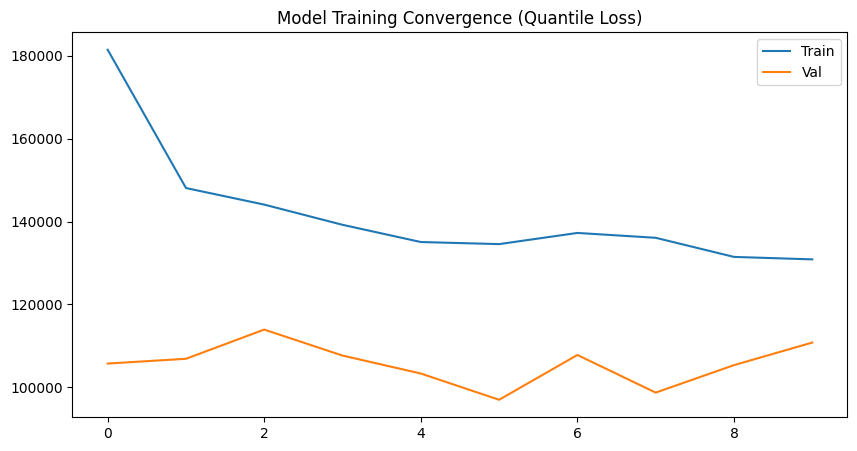

In [170]:
import torch
import matplotlib.pyplot as plt
checkpoint_path = '../models/checkpoint_latest.pt'
if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    plt.figure(figsize=(10, 5))
    plt.plot(ckpt['train_losses'], label='Train')
    plt.plot(ckpt['val_losses'], label='Val')
    plt.title('Model Training Convergence (Quantile Loss)')
    plt.legend()
    plt.show()
else:
    print("Checkpoint not found. Run training first.")

## 6. Live Inference Example

Compare the AI's valuation with the actual market price.

In [171]:
from src.training.dataset import PropertyDataset, collate_fn
from src.services.fusion_model import PropertyFusionModel
import torch
import numpy as np

# Set up dataset and sample
ds = PropertyDataset(db_path='../data/listings.db', use_vlm=True)
idx = np.random.randint(0, len(ds))
item = ds[idx]
batch = collate_fn([item])

# Load Model
model = PropertyFusionModel(hidden_dim=64, num_heads=2) # Compact settings
if os.path.exists('../models/fusion_model.pt'):
    model.load_state_dict(torch.load('../models/fusion_model.pt', map_location='cpu'))
    model.eval()
    with torch.no_grad():
        q, _, _, _ = model(
            target_tab=batch['target_tab'], 
            target_text=batch['target_text'],
            comp_tab=batch['comp_tab'], 
            comp_text=batch['comp_text'], 
            comp_prices=batch['comp_prices']
        )
        
    actual = batch['target_price'][0].item()
    pred = q[0, 1].item()
    print(f"Title: {ds.listings[idx]['title']}")
    print(f"Actual: €{actual:,.0f} | Predicted: €{pred:,.0f} | Error: {abs(actual-pred)/actual*100:.1f}%")
else:
    print("Model weights not found. Prediction skipped.")

2026-01-13 00:27:02 [info     ] text_encoder_initialized       dim=384 model=all-MiniLM-L6-v2
2026-01-13 00:27:02 [info     ] dataset_initialized            db_path=../data/listings.db num_cities=567 num_listings=1701 vlm_enabled=True
2026-01-13 00:27:02 [info     ] tabular_encoder_fitted         features=10
2026-01-13 00:27:02 [info     ] tabular_encoder_fitted         num_samples=1701
2026-01-13 00:27:02 [info     ] vlm_available                  model=llava
Model weights not found. Prediction skipped.


### 3.4 Feature Distributions

Let's create violin plots for all numerical features to understand their distributions.

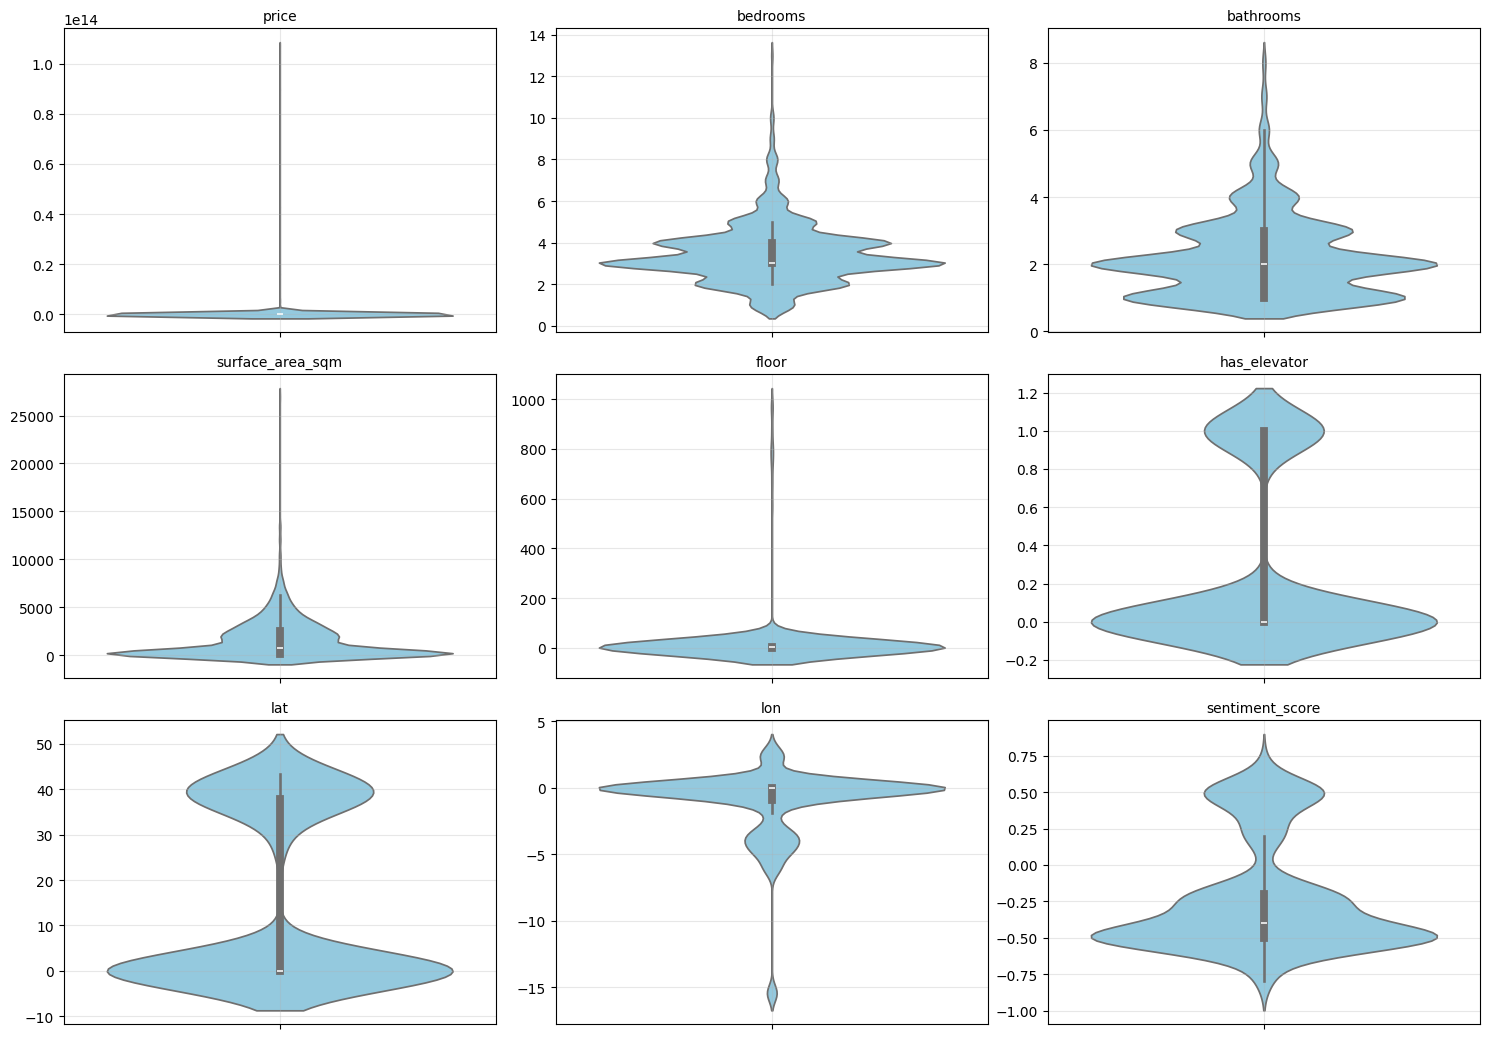

In [172]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Set up a more compact plotting layout
n_cols = 3  # Increased columns for compactness
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Reduced height multiplier to make it more compact vertically
plt.figure(figsize=(15, 3.5 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.violinplot(y=df[col], color='skyblue')
    plt.title(f'{col}', fontsize=10)
    plt.ylabel('') # Remove y-label to save space, usually title is enough
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()